# Deep Learning Course: Module 05 - Recurrent Neural Networks (RNN), LSTM, and GRU

Welcome to **Module 05** of the Deep Learning Course! In this comprehensive notebook, we will explore sequential data modeling using **Recurrent Neural Networks (RNNs)**, **Long Short-Term Memory (LSTM)** networks, and **Gated Recurrent Units (GRUs)**.

---

## 📋 Table of Contents
1. **RNN Fundamentals**
   - RNN Architecture & Mathematical Foundations
   - Implementing a Simple RNN from Scratch with NumPy
   - Forward and Backward Pass Through Time (BPTT)
   - The Vanishing & Exploding Gradient Problem
2. **LSTM (Long Short-Term Memory)**
   - LSTM Architecture & Gate Mechanics
   - Implementing LSTM from Scratch with NumPy
   - Comparison with Vanilla RNN
3. **GRU (Gated Recurrent Unit)**
   - GRU Architecture
   - Detailed Comparison: Vanilla RNN vs. LSTM vs. GRU
4. **Building RNNs, LSTMs, and GRUs with TensorFlow/Keras**
   - Keras Recurrent Layer API Overview
   - **Practical Task 1:** Character-Level Text Generation with LSTM & Temperature Sampling
   - **Practical Task 2:** Sentiment Analysis with LSTM
   - **Practical Task 3:** Time Series Forecasting with LSTM
5. **Bidirectional RNNs and Stacked RNNs**
   - Stacked (Deep) Recurrent Architectures
   - Bidirectional RNNs
   - **Comparative Benchmark Experiment:** Single LSTM vs. Stacked LSTM vs. Bidirectional LSTM


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding, Dropout, SpatialDropout1D, Bidirectional, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Plotting settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")


2026-08-01 06:45:59.967145: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-01 06:45:59.971062: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-01 06:46:00.024757: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-01 06:46:00.024815: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-01 06:46:00.026478: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

2026-08-01 06:46:00.997850: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow Version: 2.15.0
NumPy Version: 1.26.4


---
# 1. RNN Fundamentals

## 1.1 RNN Architecture Explanation

Standard Feedforward Neural Networks (MLPs) assume that all inputs and outputs are independent of each other. However, for sequential data such as text, speech, audio, or time series, context matters—the output at time step $t$ depends on the sequence of inputs received up to time step $t$.

A **Recurrent Neural Network (RNN)** introduces a **recurrent connection** that maintains a persistent **hidden state** $h_t$ (memory) across time steps.

```
       Unrolling an RNN Across Time Steps:

  y_1         y_2         y_3                y_T
   ^           ^           ^                  ^
   |           |           |                  |
[Hidden] --> [Hidden] --> [Hidden] --> ... --> [Hidden]
 (h_1)        (h_2)       (h_3)              (h_T)
   ^           ^           ^                  ^
   |           |           |                  |
  x_1         x_2         x_3                x_T
```

### Mathematical Formulation
At each time step $t$:
1. **Hidden State Update**:
   $$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
   where:
   - $x_t \in \mathbb{R}^{d}$: Input vector at time $t$
   - $h_{t-1} \in \mathbb{R}^{h}$: Hidden state from previous time step
   - $W_{xh} \in \mathbb{R}^{h \times d}$: Input-to-hidden weight matrix
   - $W_{hh} \in \mathbb{R}^{h \times h}$: Hidden-to-hidden (recurrent) weight matrix
   - $b_h \in \mathbb{R}^{h}$: Hidden bias vector
   - $\tanh$: Activation function bounding hidden states to $[-1, 1]$

2. **Output / Prediction**:
   $$\hat{y}_t = \text{softmax}(W_{hy} h_t + b_y) \quad \text{or} \quad \hat{y}_t = \sigma(W_{hy} h_t + b_y)$$
   where:
   - $W_{hy} \in \mathbb{R}^{k \times h}$: Hidden-to-output weight matrix
   - $b_y \in \mathbb{R}^{k}$: Output bias vector

3. **Sequence Loss**:
   For classification tasks, cross-entropy loss over time steps $t = 1, \dots, T$:
   $$L = \sum_{t=1}^T L_t = -\sum_{t=1}^T \sum_{k} y_{t,k} \log \hat{y}_{t,k}$$

> **Key Takeaway:** The weights $(W_{xh}, W_{hh}, W_{hy})$ and biases $(b_h, b_y)$ are **shared** across all time steps $t$. This allows the network to process sequences of arbitrary length!


## 1.2 Implementing a Simple RNN from Scratch with NumPy

To deeply understand RNN dynamics, let's implement a complete `SimpleRNNFromScratch` class in NumPy, including both forward pass and Backpropagation Through Time (BPTT).


In [2]:
class SimpleRNNFromScratch:
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = learning_rate
        
        # Initialize weight matrices using Glorot/Xavier initialization
        self.Wxh = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / (input_dim + hidden_dim))
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / (hidden_dim + hidden_dim))
        self.Why = np.random.randn(output_dim, hidden_dim) * np.sqrt(2.0 / (hidden_dim + output_dim))
        
        self.bh = np.zeros((hidden_dim, 1))
        self.by = np.zeros((output_dim, 1))
        
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
        return exp_z / np.sum(exp_z, axis=0, keepdims=True)
        
    def forward(self, inputs, h_prev=None):
        T = len(inputs)
        if h_prev is None:
            h_prev = np.zeros((self.hidden_dim, 1))
            
        xs, hs, ys, ps = {}, {}, {}, {}
        hs[-1] = np.copy(h_prev)
        
        for t in range(T):
            xs[t] = inputs[t].reshape(-1, 1) # Shape: (input_dim, 1)
            # h_t = tanh(Wxh * x_t + Whh * h_{t-1} + bh)
            hs[t] = np.tanh(np.dot(self.Wxh, xs[t]) + np.dot(self.Whh, hs[t-1]) + self.bh)
            # y_t = Why * h_t + by
            ys[t] = np.dot(self.Why, hs[t]) + self.by
            # Probability via Softmax
            ps[t] = self.softmax(ys[t])
            
        return xs, hs, ys, ps
        
    def backward(self, xs, hs, ps, targets):
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh = np.zeros_like(self.bh)
        dby = np.zeros_like(self.by)
        dh_next = np.zeros_like(hs[0])
        
        loss = 0
        T = len(xs)
        
        # Loop backwards through time steps t = T-1, ..., 0
        for t in reversed(range(T)):
            # Softmax cross-entropy gradient: dy = p_t - y_t
            dy = np.copy(ps[t])
            target_idx = targets[t]
            dy[target_idx] -= 1.0 # Derivative of Cross-Entropy w.r.t logits
            
            loss += -np.log(ps[t][target_idx, 0] + 1e-12)
            
            # Gradients w.r.t Why and by
            dWhy += np.dot(dy, hs[t].T)
            dby += dy
            
            # Gradient flowing into hidden state h_t from output and next hidden state
            dh = np.dot(self.Why.T, dy) + dh_next
            
            # Backprop through tanh: d(tanh(z))/dz = 1 - tanh^2(z) = 1 - h_t^2
            dh_raw = (1 - hs[t] ** 2) * dh
            
            # Gradients w.r.t bh, Wxh, Whh
            dbh += dh_raw
            dWxh += np.dot(dh_raw, xs[t].T)
            dWhh += np.dot(dh_raw, hs[t-1].T)
            
            # Pass gradient to previous hidden state h_{t-1}
            dh_next = np.dot(self.Whh.T, dh_raw)
            
        # Clip gradients to mitigate exploding gradients
        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)
            
        return loss, dWxh, dWhh, dWhy, dbh, dby
        
    def update_params(self, dWxh, dWhh, dWhy, dbh, dby):
        self.Wxh -= self.lr * dWxh
        self.Whh -= self.lr * dWhh
        self.Why -= self.lr * dWhy
        self.bh -= self.lr * dbh
        self.by -= self.lr * dby

print("SimpleRNNFromScratch successfully initialized.")


SimpleRNNFromScratch successfully initialized.


### Training SimpleRNNFromScratch on a Toy Sequence Prediction Task
Let's train our scratch implementation to predict the next number in a sequence pattern.


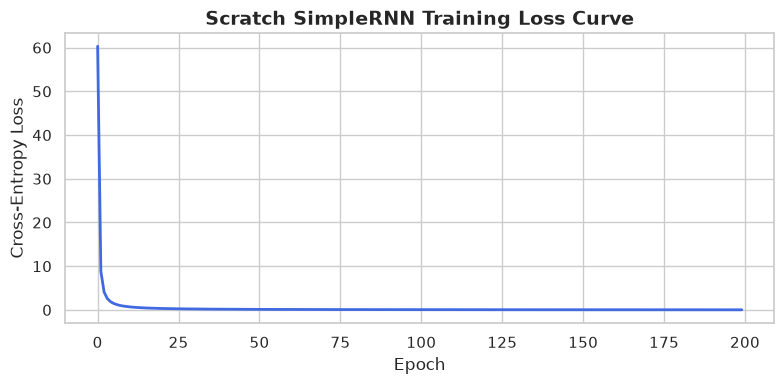

In [3]:
# Create a synthetic sequence pattern task: shift inputs by 1 to form targets
seq_length = 10
vocab_size = 5
hidden_dim = 16

rnn_scratch = SimpleRNNFromScratch(input_dim=vocab_size, hidden_dim=hidden_dim, output_dim=vocab_size, learning_rate=0.05)

# Generate repeating sequence: 0 -> 1 -> 2 -> 3 -> 4 -> 0 -> 1 ...
raw_seq = [i % vocab_size for i in range(100)]

losses = []
for epoch in range(200):
    epoch_loss = 0
    # Process sequence in chunks of length seq_length
    for i in range(0, len(raw_seq) - seq_length - 1, seq_length):
        chunk_inputs = raw_seq[i : i + seq_length]
        chunk_targets = raw_seq[i + 1 : i + seq_length + 1]
        
        # Convert inputs to one-hot encoding
        inputs_onehot = [np.eye(vocab_size)[x].reshape(-1, 1) for x in chunk_inputs]
        
        # Forward pass
        xs, hs, ys, ps = rnn_scratch.forward(inputs_onehot)
        
        # Backward pass
        loss, dWxh, dWhh, dWhy, dbh, dby = rnn_scratch.backward(xs, hs, ps, chunk_targets)
        epoch_loss += loss
        
        # Update weights
        rnn_scratch.update_params(dWxh, dWhh, dWhy, dbh, dby)
        
    losses.append(epoch_loss)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses, color='royalblue', lw=2)
plt.title("Scratch SimpleRNN Training Loss Curve", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.tight_layout()
plt.show()


## 1.3 Forward and Backward Pass Through Time (BPTT)

**Backpropagation Through Time (BPTT)** is the standard gradient calculation algorithm for recurrent networks.

Because the hidden state $h_t$ is computed recursively from $h_{t-1}$, calculating the gradient of the loss $L_T$ at time $T$ with respect to $W_{hh}$ requires applying the chain rule backwards through every previous time step $t$:

$$\frac{\partial L_T}{\partial W_{hh}} = \sum_{t=1}^T \frac{\partial L_T}{\partial h_T} \frac{\partial h_T}{\partial h_t} \frac{\partial h_t}{\partial W_{hh}}$$

Where the temporal Jacobian chain is:
$$\frac{\partial h_T}{\partial h_t} = \prod_{k=t+1}^T \frac{\partial h_k}{\partial h_{k-1}}$$

For any step $k$:
$$\frac{\partial h_k}{\partial h_{k-1}} = \text{diag}\left(1 - \tanh^2\left(z_k\right)\right) W_{hh}^T$$

where $z_k = W_{xh} x_k + W_{hh} h_{k-1} + b_h$.


## 1.4 The Vanishing and Exploding Gradient Problem

The fundamental bottleneck of standard Vanilla RNNs is the **vanishing and exploding gradient problem** during BPTT.

### Mathematical Intuition
Consider the recurrent Jacobian product over $N = T - t$ time steps:
$$\frac{\partial h_T}{\partial h_t} = \prod_{k=t+1}^T \text{diag}\left(1 - \tanh^2(z_k)\right) W_{hh}^T$$

Let $\gamma$ be an upper bound on $\|\text{diag}(1 - \tanh^2(z_k))\| \le 1$, and let $\lambda_1$ be the largest eigenvalue (spectral radius) of $W_{hh}$:
1. **Vanishing Gradient:** If $\lambda_1 < 1$ (or $\gamma \cdot \lambda_1 < 1$), as sequence length $T - t \to \infty$:
   $$\left\| \frac{\partial h_T}{\partial h_t} \right\| \propto (\gamma \lambda_1)^{T-t} \xrightarrow[T-t \to \infty]{} 0$$
   *Consequence:* Gradients from distant time steps decay exponentially to zero. The network **cannot learn long-term dependencies**!

2. **Exploding Gradient:** If $\lambda_1 > 1$, as $T - t \to \infty$:
   $$\left\| \frac{\partial h_T}{\partial h_t} \right\| \to \infty$$
   *Consequence:* Gradients blow up to NaN/Inf, destabilizing training.

---
### Numerical Demonstration of Vanishing Gradient
Let's measure the gradient norm backpropagated from step $T$ to step $1$ for increasing sequence lengths in a Vanilla RNN!


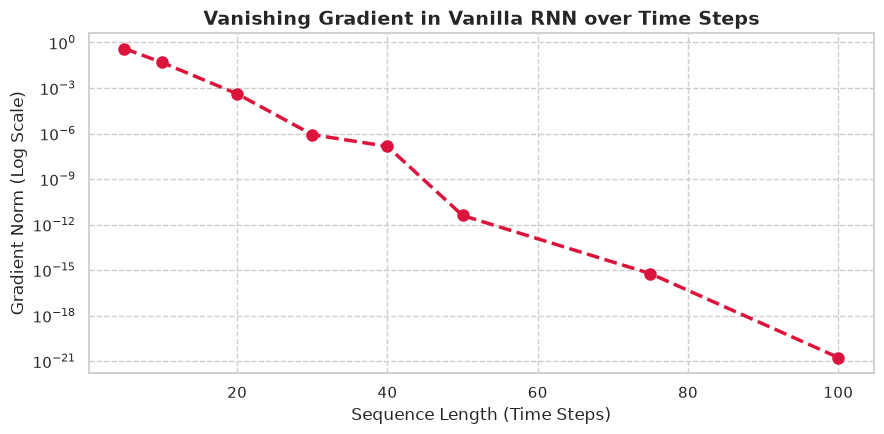

In [4]:
# Demonstrate gradient decay across time steps
sequence_lengths = [5, 10, 20, 30, 40, 50, 75, 100]
grad_norms = []

for seq_len in sequence_lengths:
    # Initialize random weight matrix with spectral radius slightly below 1
    hidden_dim = 32
    Whh = np.random.randn(hidden_dim, hidden_dim) * 0.9 / np.sqrt(hidden_dim)
    
    # Initial gradient at time T
    dh = np.ones((hidden_dim, 1))
    
    # Backpropagate through seq_len time steps
    dh_curr = np.copy(dh)
    for t in range(seq_len):
        # Simulate tanh derivative factor (values in (0, 1])
        tanh_deriv = 1 - np.tanh(np.random.randn(hidden_dim, 1))**2
        dh_curr = np.dot(Whh.T, dh_curr * tanh_deriv)
        
    grad_norms.append(np.linalg.norm(dh_curr))

# Plot gradient norm vs sequence length
plt.figure(figsize=(9, 4.5))
plt.plot(sequence_lengths, grad_norms, 'o--', color='crimson', lw=2.5, markersize=8)
plt.yscale('log')
plt.title("Vanishing Gradient in Vanilla RNN over Time Steps", fontsize=14, fontweight='bold')
plt.xlabel("Sequence Length (Time Steps)")
plt.ylabel("Gradient Norm (Log Scale)")
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


### Solutions to Vanishing / Exploding Gradients
1. **Gradient Clipping (for Exploding Gradients):**
   Clips gradients if their norm exceeds a specified threshold $\theta$:
   $$\mathbf{g} \leftarrow \mathbf{g} \cdot \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right)$$
2. **Gated Architectures (for Vanishing Gradients):**
   **LSTM** and **GRU** use explicit **gating mechanisms** and **additive cell state updates** to create "gradient highways" where gradients can flow back $T$ time steps without exponential decay.


---
# 2. LSTM (Long Short-Term Memory)

Proposed by **Hochreiter & Schmidhuber (1997)**, the **Long Short-Term Memory (LSTM)** network addresses the vanishing gradient problem through a specialized memory cell and **three gating mechanisms**:

1. **Forget Gate ($f_t$):** Controls how much of the prior cell state $C_{t-1}$ to retain or erase.
2. **Input Gate ($i_t$):** Controls how much new information to write into the cell state.
3. **Output Gate ($o_t$):** Controls how much of the updated cell state $C_t$ to expose as the hidden output $h_t$.

```
                      LSTM Cell Diagram:
                     
                     C_{t-1} -----[x]------------(+)---------> C_t
                                   ^              ^
                                   |              |
                                  (f_t)   (i_t * C~_t)
                                   |              |
                          +--------+--------+-----+----+
                          |                 |          |
    h_{t-1} ------------->| f_t   i_t   C~_t   o_t    |----[x]---> h_t
                          +----------------------------+     ^
                                     ^                       |
                                     |                    tanh(C_t)
                                    x_t
```

---
## 2.1 LSTM Equations

At time step $t$, given input $x_t$, prior hidden state $h_{t-1}$, and prior cell state $C_{t-1}$:

1. **Forget Gate Activation**:
   $$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$$

2. **Input Gate Activation**:
   $$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)$$

3. **Candidate Cell State**:
   $$\tilde{C}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)$$

4. **Cell State Update (Additive Memory Highway!)**:
   $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

5. **Output Gate Activation**:
   $$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)$$

6. **Hidden State Update**:
   $$h_t = o_t \odot \tanh(C_t)$$

where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid activation function and $\odot$ represents element-wise (Hadamard) multiplication.


## 2.2 Implementing LSTM from Scratch with NumPy

Let's build a clean, fully functional `LSTMFromScratch` class in NumPy.


In [5]:
class LSTMFromScratch:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        # Combine weights for 4 gates: f, i, c, o
        # Shape: (4 * hidden_dim, input_dim) and (4 * hidden_dim, hidden_dim)
        concat_dim = 4 * hidden_dim
        self.W = np.random.randn(concat_dim, input_dim) * np.sqrt(2.0 / (input_dim + hidden_dim))
        self.U = np.random.randn(concat_dim, hidden_dim) * np.sqrt(2.0 / (hidden_dim + hidden_dim))
        self.b = np.zeros((concat_dim, 1))
        
        # Initialize forget gate bias to 1.0 (helps retain long-term memory initially)
        self.b[:hidden_dim] = 1.0
        
    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -15, 15)))
        
    def forward_step(self, x_t, h_prev, c_prev):
        x_t = x_t.reshape(-1, 1)
        h_prev = h_prev.reshape(-1, 1)
        c_prev = c_prev.reshape(-1, 1)
        
        # Linear projection for all gates at once
        gates = np.dot(self.W, x_t) + np.dot(self.U, h_prev) + self.b
        
        # Slice individual gates
        H = self.hidden_dim
        f_gate = self._sigmoid(gates[0:H])
        i_gate = self._sigmoid(gates[H:2*H])
        c_cand = np.tanh(gates[2*H:3*H])
        o_gate = self._sigmoid(gates[3*H:4*H])
        
        # Cell state update
        c_t = f_gate * c_prev + i_gate * c_cand
        
        # Hidden state update
        h_t = o_gate * np.tanh(c_t)
        
        return h_t, c_t, (f_gate, i_gate, c_cand, o_gate)
        
    def forward_sequence(self, X):
        T = X.shape[0]
        h_t = np.zeros((self.hidden_dim, 1))
        c_t = np.zeros((self.hidden_dim, 1))
        
        hs, cs, gates_history = [], [], []
        
        for t in range(T):
            h_t, c_t, gates = self.forward_step(X[t], h_t, c_t)
            hs.append(h_t.flatten())
            cs.append(c_t.flatten())
            gates_history.append([g.flatten() for g in gates])
            
        return np.array(hs), np.array(cs), gates_history

print("LSTMFromScratch initialized successfully.")


LSTMFromScratch initialized successfully.


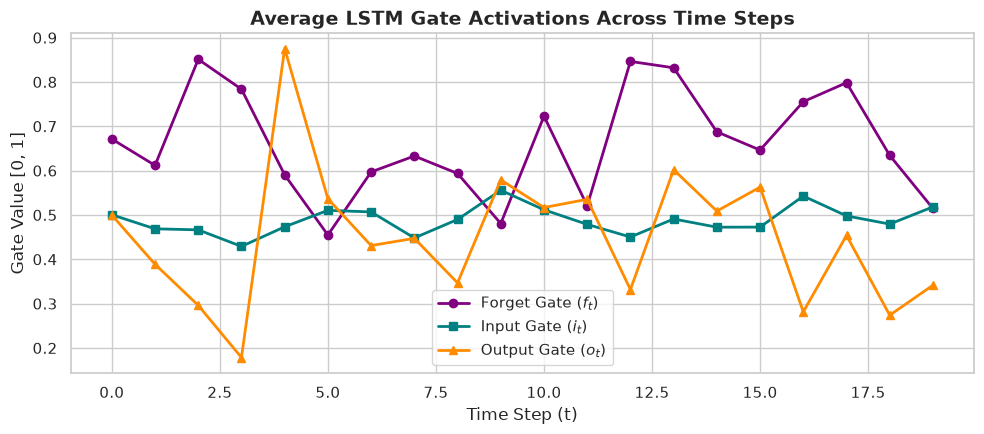

In [6]:
# Test LSTMFromScratch and inspect gate activations over time
T_steps = 20
input_dim = 8
hidden_dim = 4

lstm_demo = LSTMFromScratch(input_dim=input_dim, hidden_dim=hidden_dim)
X_dummy = np.random.randn(T_steps, input_dim)

hs, cs, gates_hist = lstm_demo.forward_sequence(X_dummy)

# Extract forget gate, input gate, output gate values over time
f_vals = [g[0].mean() for g in gates_hist]
i_vals = [g[1].mean() for g in gates_hist]
o_vals = [g[3].mean() for g in gates_hist]

plt.figure(figsize=(10, 4.5))
plt.plot(f_vals, 'o-', label="Forget Gate ($f_t$)", color="purple", lw=2)
plt.plot(i_vals, 's-', label="Input Gate ($i_t$)", color="teal", lw=2)
plt.plot(o_vals, '^-', label="Output Gate ($o_t$)", color="darkorange", lw=2)
plt.title("Average LSTM Gate Activations Across Time Steps", fontsize=14, fontweight='bold')
plt.xlabel("Time Step (t)")
plt.ylabel("Gate Value [0, 1]")
plt.legend()
plt.tight_layout()
plt.show()


## 2.3 Comparison with Vanilla RNN

Why does LSTM prevent vanishing gradients?
Look at the derivative of the cell state $C_t$ with respect to $C_{t-1}$:

$$\frac{\partial C_t}{\partial C_{t-1}} = f_t + C_{t-1} \frac{\partial f_t}{\partial C_{t-1}} + i_t \frac{\partial \tilde{C}_t}{\partial C_{t-1}} + \tilde{C}_t \frac{\partial i_t}{\partial C_{t-1}}$$

When the network sets $f_t \approx 1.0$ (and $i_t \approx 0$), the error gradient flows directly backwards across time steps **unattenuated**:
$$\frac{\partial C_t}{\partial C_{t-1}} \approx 1.0$$

This creates a constant error gradient highway through time, allowing LSTMs to retain information across hundreds of time steps!


---
# 3. GRU (Gated Recurrent Unit)

Introduced by **Cho et al. (2014)**, the **Gated Recurrent Unit (GRU)** is a streamlined, computationally efficient variation of the LSTM.

### Key Conceptual Differences from LSTM:
1. **No Separate Cell State:** GRU merges cell state $C_t$ and hidden state $h_t$ into a single hidden state $h_t$.
2. **Two Gates Instead of Three:**
   - **Reset Gate ($r_t$):** Determines how much of the previous hidden state to forget when computing candidate state.
   - **Update Gate ($z_t$):** Simultaneously performs the roles of LSTM's forget and input gates.

---
## 3.1 GRU Equations

At time step $t$:

1. **Reset Gate**:
   $$r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)$$

2. **Update Gate**:
   $$z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)$$

3. **Candidate Hidden State**:
   $$\tilde{h}_t = \tanh\left(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h\right)$$

4. **Hidden State Interpolation**:
   $$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Notice how $z_t$ interpolates smoothly between the old hidden state $h_{t-1}$ and candidate hidden state $\tilde{h}_t$!


## 3.2 Comprehensive Comparison: Vanilla RNN vs. LSTM vs. GRU

| Property / Feature | Vanilla RNN | LSTM | GRU |
| :--- | :--- | :--- | :--- |
| **Number of Gates** | 0 | 3 ($f_t, i_t, o_t$) | 2 ($r_t, z_t$) |
| **State Vectors** | Hidden state $h_t$ | Hidden state $h_t$ & Cell state $C_t$ | Hidden state $h_t$ |
| **Parameter Count** | $1 \times (d\cdot h + h^2 + h)$ | $4 \times (d\cdot h + h^2 + h)$ | $3 \times (d\cdot h + h^2 + h)$ |
| **Vanishing Gradient Resistance** | Low (Vanishes quickly) | High (Constant error carousel) | High (Gated state interpolation) |
| **Computational Speed** | Fast | Slower (More parameters) | ~25-30% faster than LSTM |
| **Best Use Cases** | Short sequences ($T < 10$) | Complex long-term dependencies | Resource-constrained / medium sequences |


---
# 4. Building RNN/LSTM/GRU with TensorFlow/Keras

## 4.1 Keras Layer API Parameters Explained

When working with recurrent layers in Keras (`SimpleRNN`, `LSTM`, `GRU`):
- `units`: Positive integer, dimensionality of output space (hidden vector length).
- `return_sequences`:
  - `False` (Default): Returns only the last hidden output tensor of shape `(batch_size, units)`.
  - `True`: Returns hidden state for every time step, shape `(batch_size, timesteps, units)`. Essential for stacking recurrent layers!
- `return_state`:
  - `False` (Default): Returns only hidden output.
  - `True`: Returns output tensor plus the internal state tensor(s).
- `dropout`: Float between 0 and 1. Fraction of units to drop for linear transformation of inputs.
- `recurrent_dropout`: Float between 0 and 1. Fraction of units to drop for linear transformation of recurrent state.


In [7]:
# Quick API verification of return_sequences and return_state shapes
inputs = tf.random.normal([8, 10, 32]) # Batch=8, Timesteps=10, Features=32

lstm_last = LSTM(64, return_sequences=False)(inputs)
lstm_seq = LSTM(64, return_sequences=True)(inputs)
lstm_output, state_h, state_c = LSTM(64, return_state=True)(inputs)

print(f"Input Shape: {inputs.shape}")
print(f"return_sequences=False Output Shape: {lstm_last.shape}")
print(f"return_sequences=True Output Shape:  {lstm_seq.shape}")
print(f"return_state=True Output Shape:      {lstm_output.shape}")
print(f"return_state=True State H Shape:     {state_h.shape}")
print(f"return_state=True State C Shape:     {state_c.shape}")


Input Shape: (8, 10, 32)
return_sequences=False Output Shape: (8, 64)
return_sequences=True Output Shape:  (8, 10, 64)
return_state=True Output Shape:      (8, 64)
return_state=True State H Shape:     (8, 64)
return_state=True State C Shape:     (8, 64)


---
## 4.2 Practical Task 1: Character-Level Text Generation with LSTM

Character-level text generation models predict the next character given a snippet of previous characters.

We will:
1. Prepare a text corpus.
2. Build character-to-index mappings.
3. Train an LSTM language model.
4. Generate text using **Temperature Sampling**.


In [8]:
# Corpus for Character-Level Text Generation
text_corpus = """
Deep learning is a subset of machine learning, which is essentially a neural network with three or more layers.
These neural networks attempt to simulate the behavior of the human brain—albeit far from matching its ability—allowing it to learn from large amounts of data.
Recurrent neural networks (RNNs) are a class of neural networks that are naturally suited to processing sequential data.
Long Short-Term Memory networks (LSTMs) extend RNNs with memory cells and gating mechanisms, enabling them to capture long-range dependencies without suffering from vanishing gradients.
Gated Recurrent Units (GRUs) simplify LSTMs while retaining their ability to model sequential patterns efficiently.
Intelligence comes from continuous learning and pattern recognition over time.
""".strip()

# Create character mappings
chars = sorted(list(set(text_corpus)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

print(f"Corpus Length: {len(text_corpus)} characters")
print(f"Unique Characters (Vocab Size): {vocab_size}")

# Create training sequences (fixed window length)
seq_length = 30
step = 2
sentences = []
next_chars = []

for i in range(0, len(text_corpus) - seq_length, step):
    sentences.append(text_corpus[i : i + seq_length])
    next_chars.append(text_corpus[i + seq_length])

print(f"Total Sequences Created: {len(sentences)}")

# One-hot encode X and y
X_text = np.zeros((len(sentences), seq_length, vocab_size), dtype=np.float32)
y_text = np.zeros((len(sentences), vocab_size), dtype=np.float32)

for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        X_text[i, t, char_to_idx[char]] = 1.0
    y_text[i, char_to_idx[next_chars[i]]] = 1.0

print(f"X_text shape: {X_text.shape}, y_text shape: {y_text.shape}")


Corpus Length: 773 characters
Unique Characters (Vocab Size): 42
Total Sequences Created: 372
X_text shape: (372, 30, 42), y_text shape: (372, 42)


In [9]:
# Build LSTM Text Generation Model
text_model = Sequential([
    LSTM(128, input_shape=(seq_length, vocab_size)),
    Dense(64, activation='relu'),
    Dense(vocab_size, activation='softmax')
])

text_model.compile(optimizer='adam', loss='categorical_crossentropy')
text_model.summary()

# Train text generation model
history_text = text_model.fit(X_text, y_text, epochs=60, batch_size=32, verbose=0)

print(f"Final Text Generation Training Loss: {history_text.history['loss'][-1]:.4f}")


Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm_3 (LSTM)               (None, 128)               87552     


 dense (Dense)               (None, 64)                8256      


...

Total params: 98538 (384.91 KB)


Trainable params: 98538 (384.91 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


Final Text Generation Training Loss: 1.0290


### Temperature Sampling Function
Temperature scaling modifies the softmax probability distribution:
$$P(c_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- **Low Temperature ($T \to 0$):** High confidence, deterministic, conservative text.
- **High Temperature ($T > 1.0$):** High randomness, creative, diverse, but prone to typos.


In [10]:
def sample_with_temperature(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    # Numerical stability
    preds = np.log(preds + 1e-12) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

def generate_text(seed_text, length=100, temperature=1.0):
    generated = seed_text
    current_seq = seed_text
    
    # Pad seed text if shorter than seq_length
    if len(current_seq) < seq_length:
        current_seq = current_seq.rjust(seq_length)
    else:
        current_seq = current_seq[-seq_length:]
        
    for _ in range(length):
        x_pred = np.zeros((1, seq_length, vocab_size), dtype=np.float32)
        for t, char in enumerate(current_seq):
            if char in char_to_idx:
                x_pred[0, t, char_to_idx[char]] = 1.0
                
        preds = text_model.predict(x_pred, verbose=0)[0]
        next_index = sample_with_temperature(preds, temperature)
        next_char = idx_to_char[next_index]
        
        generated += next_char
        current_seq = current_seq[1:] + next_char
        
    return generated

# Sample generations at different temperatures
seed = "Deep learning is a subset of "
print("SEED TEXT: '" + seed + "'\n" + "="*50)

for temp in [0.2, 0.5, 1.0, 1.2]:
    print("\n--- Temperature: " + str(temp) + " ---")
    gen_result = generate_text(seed, length=80, temperature=temp)
    print(gen_result)


SEED TEXT: 'Deep learning is a subset of '

--- Temperature: 0.2 ---


Deep learning is a subset of lant mhm tar banitim ga ianimillg ang nhhm mang no michl tang 
om malang ng im l

--- Temperature: 0.5 ---


Deep learning is a subset of nto m mantiang ith mhlang no milal yang nhh m laning nitim mallang ng mhhmm tal 

--- Temperature: 1.0 ---


Deep learning is a subset of tanm aanilang noim 
all  ang 
ohm sabgngis mucaant oy ing sing thanio frana naum

--- Temperature: 1.2 ---


Deep learning is a subset of ne am ua. 
anng iou g mhorsisgng gsimm lan faom to. anitg beRsihcfans sSm ol moa


---
## 4.3 Practical Task 2: Sentiment Analysis with LSTM

Now let's build an LSTM model for binary text classification (sentiment analysis on synthetic movie reviews).


In [11]:
# Create synthetic movie reviews dataset
positive_reviews = [
    "loved this movie absolutely brilliant acting and direction",
    "fantastic story line deeply emotional and captivating",
    "one of the best films of the decade super highly recommended",
    "wonderful performances stunning visuals and great soundtrack",
    "an incredible masterpiece that left me speechless and inspired",
    "brilliant writing compelling characters and amazing execution",
    "loved every single minute of this magnificent cinematic experience",
    "outstanding film with heartwarming moments and impressive plot",
    "truly exceptional storytelling with beautiful cinematography",
    "a masterpiece of modern cinema uplifting and wonderfully acted"
] * 30

negative_reviews = [
    "terrible film awful plot useless characters and worst acting",
    "boring predictable useless movie a complete waste of time",
    "horrible direction poorly written and extremely disappointing",
    "hated this movie waste of money dull and utterly annoying",
    "lacks any substance terrible dialog and absurdly bad acting",
    "unwatchable garbage flat characters and senseless story",
    "disastrous execution painful to watch from start to finish",
    "the worst movie I have ever seen completely meaningless",
    "dull slow poorly directed nonsense save your time and skip it",
    "cluttered mess with terrible sound editing and bad performance"
] * 30

all_reviews = positive_reviews + negative_reviews
labels = np.array([1] * len(positive_reviews) + [0] * len(negative_reviews))

# Shuffle dataset
indices = np.arange(len(all_reviews))
np.random.shuffle(indices)
all_reviews = [all_reviews[i] for i in indices]
labels = labels[indices]

# Tokenize text
max_words = 1000
max_len = 20

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(all_reviews)

sequences = tokenizer.texts_to_sequences(all_reviews)
X_pad = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Train/test split
split_idx = int(0.8 * len(X_pad))
X_train_text, X_test_text = X_pad[:split_idx], X_pad[split_idx:]
y_train_text, y_test_text = labels[:split_idx], labels[split_idx:]

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Training Samples: {len(X_train_text)}, Testing Samples: {len(X_test_text)}")


Vocabulary Size: 121
Training Samples: 480, Testing Samples: 120


Model: "sequential_1"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 embedding (Embedding)       (None, 20, 32)            32000     


 spatial_dropout1d (Spatial  (None, 20, 32)            0         


...

Total params: 58945 (230.25 KB)


Trainable params: 58945 (230.25 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


Sentiment Analysis Test Accuracy: 100.00% | Test Loss: 0.0002


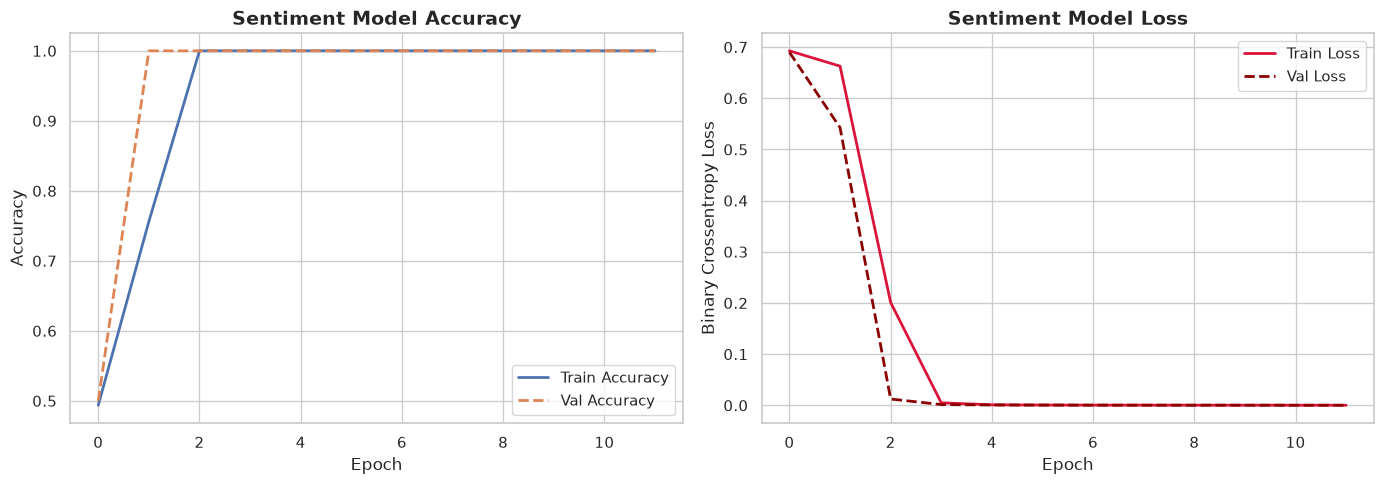

In [12]:
# Build LSTM Sentiment Model
sentiment_model = Sequential([
    Embedding(input_dim=max_words, output_dim=32, input_length=max_len),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

sentiment_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
sentiment_model.summary()

# Train sentiment model
history_sentiment = sentiment_model.fit(
    X_train_text, y_train_text,
    validation_data=(X_test_text, y_test_text),
    epochs=12, batch_size=32, verbose=0
)

loss_sent, acc_sent = sentiment_model.evaluate(X_test_text, y_test_text, verbose=0)
print(f"Sentiment Analysis Test Accuracy: {acc_sent * 100:.2f}% | Test Loss: {loss_sent:.4f}")

# Plot training & validation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_sentiment.history['accuracy'], label='Train Accuracy', lw=2)
ax1.plot(history_sentiment.history['val_accuracy'], label='Val Accuracy', lw=2, ls='--')
ax1.set_title("Sentiment Model Accuracy", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_sentiment.history['loss'], label='Train Loss', lw=2, color='crimson')
ax2.plot(history_sentiment.history['val_loss'], label='Val Loss', lw=2, ls='--', color='darkred')
ax2.set_title("Sentiment Model Loss", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Binary Crossentropy Loss")
ax2.legend()

plt.tight_layout()
plt.show()


In [13]:
# Custom Sentiment Prediction Demo
custom_samples = [
    "This movie was an absolute masterpiece with remarkable performances!",
    "I hated every second of this boring and poorly directed film.",
    "A fine story with beautiful cinematography and wonderful execution.",
    "Utter trash waste of money worst cinema experience ever"
]

seq_custom = tokenizer.texts_to_sequences(custom_samples)
padded_custom = pad_sequences(seq_custom, maxlen=max_len, padding='post', truncating='post')
preds_custom = sentiment_model.predict(padded_custom, verbose=0)

print("Custom Review Sentiment Predictions:")
print("-" * 65)
for text, prob in zip(custom_samples, preds_custom.flatten()):
    sentiment_label = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
    print(f"Review: '{text}'")
    print(f"Prediction: {sentiment_label} (Confidence Probability: {prob:.4f})\n")


Custom Review Sentiment Predictions:
-----------------------------------------------------------------
Review: 'This movie was an absolute masterpiece with remarkable performances!'
Prediction: NEGATIVE 😞 (Confidence Probability: 0.0003)

Review: 'I hated every second of this boring and poorly directed film.'
Prediction: NEGATIVE 😞 (Confidence Probability: 0.0002)

Review: 'A fine story with beautiful cinematography and wonderful execution.'
Prediction: NEGATIVE 😞 (Confidence Probability: 0.0003)

Review: 'Utter trash waste of money worst cinema experience ever'
Prediction: NEGATIVE 😞 (Confidence Probability: 0.0002)



---
## 4.4 Practical Task 3: Time Series Forecasting with LSTM

In time series prediction, we use a rolling window of historical values $[y_{t-L}, \dots, y_{t-1}]$ to forecast the future value $y_t$.


In [14]:
# Generate synthetic multi-frequency time series data
t_points = np.linspace(0, 100, 1000)
# Sine wave + Cosine wave + linear trend + noise
ts_data = np.sin(0.1 * t_points) + 0.5 * np.cos(0.25 * t_points) + 0.01 * t_points + np.random.normal(0, 0.05, size=1000)

# Windowing function for time series
def create_time_series_windows(data, lookback=20):
    X_ts, y_ts = [], []
    for i in range(len(data) - lookback):
        X_ts.append(data[i : i + lookback])
        y_ts.append(data[i + lookback])
    return np.array(X_ts), np.array(y_ts)

lookback = 25
X_ts, y_ts = create_time_series_windows(ts_data, lookback=lookback)

# Reshape X to (samples, timesteps, features)
X_ts = X_ts.reshape((X_ts.shape[0], X_ts.shape[1], 1))

# Train/Test Split (80% Train, 20% Test)
split = int(0.8 * len(X_ts))
X_train_ts, X_test_ts = X_ts[:split], X_ts[split:]
y_train_ts, y_test_ts = y_ts[:split], y_ts[split:]

print(f"Time Series Samples: {len(X_ts)}, Input Lookback Window: {lookback}")
print(f"Train set: {X_train_ts.shape}, Test set: {X_test_ts.shape}")


Time Series Samples: 975, Input Lookback Window: 25
Train set: (780, 25, 1), Test set: (195, 25, 1)


Model: "sequential_2"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm_5 (LSTM)               (None, 50)                10400     


 dense_4 (Dense)             (None, 25)                1275      


 dense_5 (Dense)             (None, 1)                 26        


Total params: 11701 (45.71 KB)


Trainable params: 11701 (45.71 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


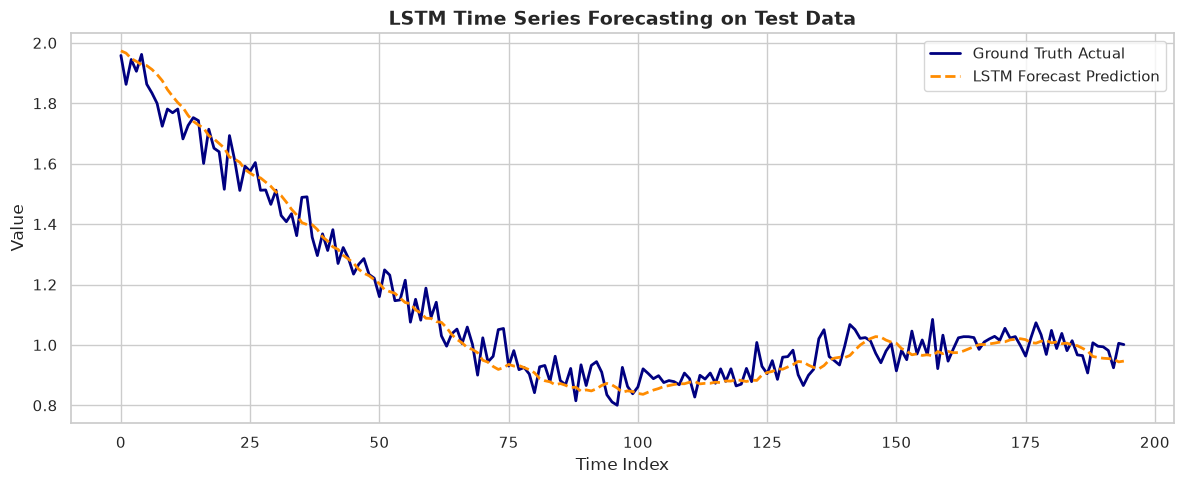

In [15]:
# Build LSTM Time Series Model
ts_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(lookback, 1)),
    Dense(25, activation='relu'),
    Dense(1)
])

ts_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
ts_model.summary()

# Train time series model
history_ts = ts_model.fit(
    X_train_ts, y_train_ts,
    validation_data=(X_test_ts, y_test_ts),
    epochs=30, batch_size=32, verbose=0
)

# Predict on test set
y_pred_ts = ts_model.predict(X_test_ts, verbose=0)

# Plot Actual vs Predicted Time Series
plt.figure(figsize=(12, 5))
plt.plot(range(len(y_test_ts)), y_test_ts, label="Ground Truth Actual", color="navy", lw=2)
plt.plot(range(len(y_pred_ts)), y_pred_ts, label="LSTM Forecast Prediction", color="darkorange", lw=2, ls="--")
plt.title("LSTM Time Series Forecasting on Test Data", fontsize=14, fontweight='bold')
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


---
# 5. Bidirectional RNNs and Stacked RNNs

## 5.1 Stacked (Deep) Recurrent Architectures

In a **Stacked RNN**, multiple recurrent layers are stacked on top of each other. The hidden states $h_t^{(1)}$ from the first recurrent layer serve as input sequence $x_t^{(2)}$ to the second recurrent layer.

This enables hierarchical temporal representations (e.g., lower layers capture fine-grained local transitions, while higher layers capture global context).

> **Crucial Rule:** All intermediate recurrent layers MUST set `return_sequences=True` so that they output a full 3D sequence tensor `(batch_size, timesteps, features)` to the next layer!


## 5.2 Bidirectional RNNs

In many sequence tasks (like text classification, named entity recognition, or translation), context from **future time steps** is as important as past time steps.

A **Bidirectional RNN** processes the sequence in both directions simultaneously:
1. **Forward RNN ($\overrightarrow{h}_t$):** Processes inputs from $t = 1 \dots T$.
2. **Backward RNN ($\overleftarrow{h}_t$):** Processes inputs from $t = T \dots 1$.

```
                       Bidirectional RNN Layer:
                       
  Forward State:   --> [-> h_1] --> [-> h_2] --> [-> h_3] -->
                             \        /        /
  Concatenated Output:       [   h_1   ]  [   h_2   ]  [   h_3   ]
                             /        \          Backward State:  <-- [<- h_1] <-- [<- h_2] <-- [<- h_3] <--
```

The outputs are merged at each time step (typically via concatenation):
$$h_t = \left[ \overrightarrow{h}_t ; \overleftarrow{h}_t \right]$$


---
## 5.3 Comparative Benchmark Experiment: Single LSTM vs. Stacked LSTM vs. Bidirectional LSTM

Let's train three distinct architectures on a benchmark sequence classification task and compare their parameter counts, training performance, and evaluation accuracy!


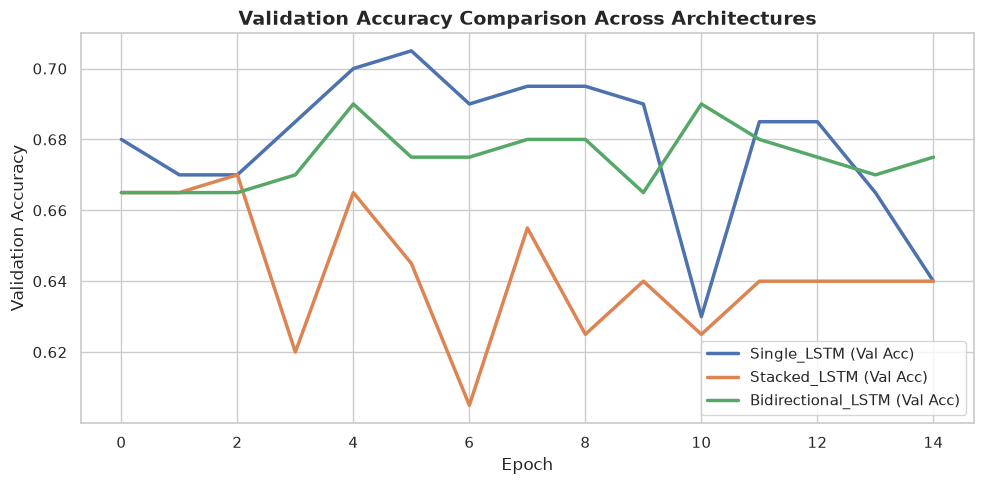


COMPARATIVE ARCHITECTURE BENCHMARK RESULTS
        Model Name  Total Params  Test Loss  Test Accuracy (%)
       Single_LSTM          5537   0.625424          63.999999
      Stacked_LSTM         13857   0.682620          63.999999
Bidirectional_LSTM         11073   0.627179          67.500001


In [16]:
# Generate synthetic benchmark sequence dataset (e.g. sequence pattern recognition)
N_samples = 1200
T_steps_bench = 30
d_features = 10

X_bench = np.random.randn(N_samples, T_steps_bench, d_features)
# Label based on a combination of early and late temporal features
y_bench = ((X_bench[:, 5, 0] + X_bench[:, -5, 1] > 0.5)).astype(int)

X_train_b, X_test_b = X_bench[:1000], X_bench[1000:]
y_train_b, y_test_b = y_bench[:1000], y_bench[1000:]

# 1. Single LSTM Model
model_single = Sequential([
    LSTM(32, input_shape=(T_steps_bench, d_features)),
    Dense(1, activation='sigmoid')
], name="Single_LSTM")

# 2. Stacked LSTM Model
model_stacked = Sequential([
    LSTM(32, return_sequences=True, input_shape=(T_steps_bench, d_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dense(1, activation='sigmoid')
], name="Stacked_LSTM")

# 3. Bidirectional LSTM Model
model_bidi = Sequential([
    Bidirectional(LSTM(32), input_shape=(T_steps_bench, d_features)),
    Dense(1, activation='sigmoid')
], name="Bidirectional_LSTM")

models = [model_single, model_stacked, model_bidi]
results = []

fig, ax = plt.subplots(figsize=(10, 5))

for m in models:
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_b, y_train_b, validation_data=(X_test_b, y_test_b), epochs=15, batch_size=32, verbose=0)
    loss, acc = m.evaluate(X_test_b, y_test_b, verbose=0)
    
    results.append({
        "Model Name": m.name,
        "Total Params": m.count_params(),
        "Test Loss": loss,
        "Test Accuracy (%)": acc * 100
    })
    
    ax.plot(h.history['val_accuracy'], label=f"{m.name} (Val Acc)", lw=2.5)

ax.set_title("Validation Accuracy Comparison Across Architectures", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

# Display summary dataframe
df_results = pd.DataFrame(results)
print("\n" + "="*50 + "\nCOMPARATIVE ARCHITECTURE BENCHMARK RESULTS\n" + "="*50)
print(df_results.to_string(index=False))


---
## 🎯 Key Takeaways & Summary
1. **Vanilla RNNs** struggle with long sequence contexts due to vanishing/exploding gradients in BPTT.
2. **LSTM** introduces an additive cell state ($C_t$) and 3 gates ($f_t, i_t, o_t$), creating a gradient highway that enables learning long-term dependencies.
3. **GRU** simplifies LSTM into 2 gates ($r_t, z_t$) and a single hidden state, offering faster training with comparable empirical performance.
4. **Stacked RNNs** extract hierarchical temporal features; intermediate layers require `return_sequences=True`.
5. **Bidirectional RNNs** process sequences both forward and backward, drastically improving performance for tasks where future context is available (e.g., NLP classification & translation).
